### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

In [3]:
# !pip install -q ipython-autotime
%load_ext autotime

time: 61 μs (started: 2026-08-12 22:25:58 -07:00)


# [vk denovo](https://github.com/pachterlab/varseek) on NA12878 (GIAB HG001) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**NA12878 / HG001** whole-genome sequencing reads, then compares the calls **directly to the
Genome in a Bottle (GIAB) HG001 v4.2.1 truth set** with `hap.py` — the standard germline
small-variant benchmarking tool.

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), in the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth
comparison.

**Data**
- Reads: GIAB NIST `RMNISTHS_30xdownsample.bam` (NA12878, ~30×), chr20 reads only, re-aligned to GRCh38.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + high-confidence `.bed`, restricted to chr20
  and renamed to Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.

**What the notebook does**

1. **varseek de novo** — `vk denovo` → `vk ref` → `vk count`, scored against GIAB with `hap.py`.
2. **The general-purpose callers** — DeepVariant, GATK HaplotypeCaller, GATK Mutect2, Strelka2 and
   VarScan2, all on the *same* bowtie2 alignment, each scored against the same GIAB truth.
3. **varseek in genotyping mode** — the same reads screened against the COSMIC Cancer Mutation
   Census, scored against GIAB ∩ COSMIC.
4. **Three comparison figures** — an upset plot of call-set overlap, a precision-vs-recall scatter,
   and a runtime bar chart.


### Define paths and parameters

In [4]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")

# ---- NA12878 chr20 working dir ----
root = os.path.join("data", "na12878_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, "NA12878_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, "NA12878_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")
bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo
min_counts_denovo = 2  # min reads supporting a candidate (INFO/AO)
denovo_min_mapq = 20
denovo_min_baseq = 20
denovo_min_vaf = 0.10

# vk ref
k = 41
w = 40
max_homopolymer_length = None
min_unique_triplets = None
shorten_repetitive_regions = True
remove_alignment_to_reference = False

# vk count
pseudobam_validation = True
check_alignment_position = True
min_snp_vaf = 0.25
min_indel_vaf = 0.10
min_counts_clean = 1
min_supporting_reads = 5
# ==========================================================================

# Output directories are tagged with the parameters that produced them, so changing a setting above cannot silently reuse a previous run's hap.py summary.
run_tag = (f"seed_c{min_counts_denovo}v{int(denovo_min_vaf * 100)}"
           f"_k{k}_thr{min_supporting_reads}"
           f"{'_srr' if shorten_repetitive_regions else ''}"
           f"{'_pb' if pseudobam_validation else ''}"
           f"_snpvaf{int(min_snp_vaf * 100) if min_snp_vaf else 0}"
           f"_indelvaf{int(min_indel_vaf * 100) if min_indel_vaf else 0}")

denovo_bam_dir = os.path.join(root, "varseek_denovo_out", "bams")
variants_dir = os.path.join(root, f"varseek_denovo_out_c{min_counts_denovo}v{int(denovo_min_vaf * 100)}")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
reference_bam = os.path.join(denovo_bam_dir, "NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam")

vk_ref_out_dir = os.path.join(root, f"varseek_ref_out_{run_tag}")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")
vcrs_unfiltered_fasta_out = os.path.join(vk_ref_out_dir, "vcrs_unfiltered.fa")

vk_count_out_dir = os.path.join(root, f"varseek_count_out_{run_tag}")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")
adata_path = os.path.join(vk_count_out_dir, "adata_cleaned.h5ad")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, f"happy_output_{run_tag}")

# general
threads = 32
read_length = 148

print("run tag:", run_tag)

run tag: seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10
time: 2.18 ms (started: 2026-08-12 22:25:58 -07:00)


In [5]:
# --- Tool runtime recording -------------------------------------------------
# Every tool below (vk denovo / vk ref / vk count / DeepVariant / GATK
# HaplotypeCaller / GATK Mutect2 / Strelka2 / VarScan2) is timed, and its wall-clock runtime in
# seconds is written to `tool_runtimes.json` *immediately* after it finishes.
# Persisting to disk means a recorded time is not forgotten across kernel
# restarts, and is not lost when a later cell re-runs and skips the tool via an
# `if not os.path.exists(...)` guard (in that case the previously recorded time
# is simply kept). The three varseek stages are stored separately here for
# reference; the runtime plot at the end sums them into one "varseek" bar.
import json, time
from contextlib import contextmanager

runtime_json = os.path.join(root, "tool_runtimes.json")

def load_runtimes():
    if os.path.exists(runtime_json):
        with open(runtime_json) as fh:
            return json.load(fh)
    return {}

def save_runtime(name, seconds):
    data = load_runtimes()
    data[name] = seconds
    os.makedirs(os.path.dirname(runtime_json), exist_ok=True)
    with open(runtime_json, "w") as fh:
        json.dump(data, fh, indent=2, sort_keys=True)
    print(f"[runtime] {name}: {seconds:.1f} s ({seconds/60:.2f} min)  ->  {runtime_json}")

@contextmanager
def record_runtime(name):
    _t0 = time.perf_counter()
    try:
        yield
    finally:
        save_runtime(name, time.perf_counter() - _t0)

print(f"Runtimes will be written to: {runtime_json}")
print("Existing recorded runtimes:", load_runtimes())

Runtimes will be written to: data/na12878_chr20/tool_runtimes.json
Existing recorded runtimes: {'deepvariant': 941.5780808329582, 'haplotypecaller': 1727.4541525095701, 'mutect2': 1306.6620010212064, 'strelka2': 159.10879575833678, 'varscan': 790.2433219850063, 'vk count': 1102.0177640728652, 'vk count (COSMIC)': 3.6005392968654633, 'vk denovo': 12.764867257326841, 'vk ref': 120.20172007754445, 'vk ref (COSMIC)': 3297.9315293356776}
time: 11.5 ms (started: 2026-08-12 22:25:58 -07:00)


In [6]:
if not os.path.exists(sequences):
    sequences_dir = os.path.dirname(sequences)
    !gget ref -w dna -r 114 --out_dir {sequences_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    gtf_dir = os.path.dirname(gtf)
    !gget ref -w gtf -r 114 --out_dir {gtf_dir} -d human
    !gunzip {gtf}.gz

time: 9.52 ms (started: 2026-08-12 22:25:58 -07:00)


### Download NA12878 chr20 reads (GIAB 30× BAM) and re-align target

We stream only the **chr20** reads from the GIAB NIST 30× downsampled NA12878 BAM, then convert
them to paired FASTQ. Reads are reference-agnostic, so although that BAM is GRCh37-aligned we
re-align to GRCh38 below.

In [7]:
GIAB_30X_BAM = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/"
                "NIST_NA12878_HG001_HiSeq_300x/RMNISTHS_30xdownsample.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        subprocess.run(["samtools", "view", "-@", str(threads), "-b", GIAB_30X_BAM, "20",
                        "-o", chr20_bam], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
print(f"NA12878 chr20 read pairs: {n_pairs:,}")


NA12878 chr20 read pairs: 6,633,667
time: 16.3 s (started: 2026-08-12 22:25:58 -07:00)


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [8]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20
time: 1.23 ms (started: 2026-08-12 22:26:15 -07:00)


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it.

In [9]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "NA12878_HG001/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 83629
confident intervals (chr20): 13529
time: 661 ms (started: 2026-08-12 22:26:15 -07:00)


### Run `vk denovo`

Align the reads with **bowtie2** and read the de novo candidate variants straight off the
alignment records with the **`bam2vcf`** caller. Calling is *not* restricted to the GIAB
high-confidence BED — that restriction belongs at evaluation time, and `hap.py` applies it via
`-f {confident_bed}` below.

In [10]:
# `variant_caller="bam2vcf"` reads every variant recorded in the alignment records themselves
# (CIGAR indels plus mismatches against the reference) and writes a sites-only VCF with AO/DP/VAF.
# It is a candidate *generator*, not a genotyper: no statistical model, ~15 s instead of ~265 s for
# the bcftools mpileup/call/norm chain. That trade only works if its quality filters are set --
# min_mapq/min_baseq keep mismapped repeat reads and miscalled bases out of the candidate set.
#
# `regions` is deliberately not set: it exists to speed calling up, not to define truth. Restricting
# it to the GIAB BED would make vk denovo structurally blind to 13% of chr20 while the callers it is
# compared against range freely; hap.py already does the confident-region restriction at *evaluation*
# time via `-f {confident_bed}`.
if not os.path.exists(variants):
    with record_runtime("vk denovo"):
        vk.denovo(
            inputs=[r1, r2],
            sequences=sequences,
            parity="paired",
            aligner="bowtie2",
            bowtie2_genome_index_prefix=bowtie2_index_prefix,
            out_bam_dir=denovo_bam_dir,
            # regions=confident_bed,
            output=variants_vcf,
            output_tsv=variants,
            min_counts=min_counts_denovo,
            min_mapq=denovo_min_mapq,
            min_baseq=denovo_min_baseq,
            min_vaf=denovo_min_vaf,
            variant_caller="bam2vcf",
            read_length=read_length,
            threads=threads,
            verbose=1,
            technology="dna"
        )

variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of de novo variants: {len(variants_df):,}")
variants_df.head()

Number of de novo variants: 131,042


,seq_id,variant
0,20,g.80457C>T
1,20,g.80497_80498insT
2,20,g.81154T>G
3,20,g.82603A>C
4,20,g.83158C>T


time: 109 ms (started: 2026-08-12 22:26:15 -07:00)


### Run `vk ref`

In [11]:
if not os.path.exists(vcrs_index):
    with record_runtime("vk ref"):
        vk.ref(
            variants=variants,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=remove_alignment_to_reference,
            out=vk_ref_out_dir,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=vcrs_unfiltered_fasta_out,
            save_variants_updated_dataframe=False,
            index_out=vcrs_index,
            vcrs_t2g_out=vcrs_t2g,
            w=w,
            k=k,
            max_homopolymer_length=max_homopolymer_length,
            min_unique_triplets=min_unique_triplets,
            shorten_repetitive_regions=shorten_repetitive_regions,
            threads=threads,
        )
print("VCRS index:", vcrs_index)
print("VCRSs in the index:", sum(1 for _ in open(vcrs_t2g)))

VCRS index: data/na12878_chr20/varseek_ref_out_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/vcrs_index_denovo.idx
VCRSs in the index: 127993
time: 47.5 ms (started: 2026-08-12 22:26:15 -07:00)


### Run `vk count`

Pseudoalign the reads against the variant reference and threshold to produce the varseek variant
call set. Bulk paired-end mode (no cell barcodes).

In [12]:
if not os.path.exists(adata_path):
    with record_runtime("vk count"):
        vk_count_output_dict = vk.count(
            [r1, r2],
            index=vcrs_index,
            t2g=vcrs_t2g,
            technology="dna",
            parity="paired",
            out=vk_count_out_dir,
            k=k,
            threads=threads,
            strand="unstranded",
            min_counts=min_counts_clean,
            min_reads=min_supporting_reads,
            pseudobam_validation=pseudobam_validation,
            reference_bam=reference_bam,
            check_alignment_position=check_alignment_position,
            min_snp_vaf=min_snp_vaf,
            min_indel_vaf=min_indel_vaf,
            read_length=read_length,
            delete_intermediate_files=False,
        )
    adata_path = vk_count_output_dict["adata_path"]
print("adata:", adata_path)

adata_vcrs = ad.read_h5ad(adata_path)

adata: data/na12878_chr20/varseek_count_out_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/adata_cleaned.h5ad


time: 915 ms (started: 2026-08-12 22:26:15 -07:00)


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [13]:
def adata_to_vcf(adata, vcf_out, counts=None, min_reads=1):
    """Sites-only VCF of every VCRS with at least `min_reads` supporting reads.

    `counts` overrides the AnnData matrix; pass None to threshold on the matrix column sums,
    which with `min_reads` set are the read counts vk clean already filtered."""
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    if counts is None:
        counts = np.asarray(adata.X.sum(axis=0)).ravel()
    adata = adata[:, np.asarray(counts) >= min_reads]
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

# adata.X already holds the read counts after vk clean applied `min_reads` and the two VAF
# floors, so every column with a nonzero sum is a call and no separate indicator is needed.
adata_to_vcf(adata_vcrs, vk_count_variants_vcf, counts=None, min_reads=1)

data/na12878_chr20/varseek_count_out_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/varseek_variants.vcf already exists, skipping VCF writing.
time: 5.42 ms (started: 2026-08-12 22:26:16 -07:00)


### Direct comparison to GIAB ground truth with `hap.py`

Because NA12878 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [14]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out


os.makedirs(happy_out, exist_ok=True)
query_norm = normalize_query(vk_count_variants_vcf, sequences)

summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv):
    # All inputs/outputs live under `root` and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv)

Writing to /home/jrich/tmp/bcftools.BRPxnD


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	94324/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


hap.py summary: data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/varseek_vs_giab_truth.summary.csv
time: 2.75 s (started: 2026-08-12 22:26:16 -07:00)


### Results

In [15]:
summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
summary = pd.read_csv(summary_csv)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
view = summary[summary["Filter"] == "PASS"][cols].reset_index(drop=True)
display(view)
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls")


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,10504,9790,714,17703,186,0.932026,0.981342,0.956048
1,SNP,PASS,69210,66230,2980,76621,773,0.956943,0.988464,0.972448



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls
time: 31.9 ms (started: 2026-08-12 22:26:19 -07:00)


## Benchmark against the general-purpose callers (DeepVariant, GATK HaplotypeCaller, GATK Mutect2, Strelka2, VarScan2)

Having compared varseek's de novo calls directly to the GIAB ground truth above, we now run the
same general-purpose callers used in [`vk_denovo.ipynb`](vk_denovo.ipynb) on these NA12878
chr20 reads. Every call set is scored against the same GIAB truth, and the three
comparison figures at the end of the notebook are built from them.

Every one of them consumes the **same paired bowtie2 alignment** that `vk denovo` produced, so the
comparison isolates the variant caller rather than the aligner.

- **DeepVariant** consumes that alignment reheadered to carry the full reference contig dictionary
  (DeepVariant rejects a chr20-only BAM header as a genome-build mismatch). Because NA12878 is
  **DNA**, DeepVariant runs its standard **WGS** model here (not the RNA-seq model used in
  `vk_denovo.ipynb`); the RNA-seq model applied to genomic DNA systematically over-calls and
  produces a large block of spurious lone calls. We also keep only DeepVariant's **PASS** variant
  calls, dropping its `RefCall` (reference-genotype) records, so every caller is compared on the
  same "actual variant call" footing.
- **GATK HaplotypeCaller / Mutect2** run in the shared benchmarking scripts' **DNA mode**
  (`--dna`), which consumes the same **bowtie2** alignment and skips the RNA-seq-specific
  steps (STAR, `SplitNCigarReads`, `--dont-use-soft-clipped-bases`, and the splice-junction
  clustered-SNP `VariantFiltration`).
- **Strelka2** runs its **germline** workflow, also in the scripts' new `--dna` mode, which drops
  the `--rna` flag — Strelka's RNA-seq germline model assumes spliced reads and a wildly uneven
  depth distribution, neither of which holds for a 30x genome.
- **VarScan2** pileup-based calling (`mpileup2cns`), likewise in `--dna` mode: no exon
  restriction, and VarScan's own documented germline thresholds
  (`--min-coverage 8 --min-reads2 2 --min-var-freq 0.20 --strand-filter 1`) rather than the
  near-thresholdless settings the RNA-seq simulation benchmark uses, which on a 30x germline
  genome would promote essentially every sequencing error to a call.

Those last two read a **repaired copy** of the same BAM — same reads, same alignments, two
corrected header/flag fields. Both are sensitive to bookkeeping the other four callers ignore;
the cell below explains exactly what is changed and why leaving it alone would have benchmarked
them at a third of the sample's real depth.

VarTrix is single-cell-specific and is omitted here (this is a bulk paired-end DNA sample).


In [16]:
# --- Paths for the general-purpose callers (mirrors vk_denovo.ipynb) ---
scripts_dir = "/home/jrich/Desktop/RLSRP_2025/scripts"
star_genome_index_dir = os.path.join(reference_dir, "star_index")
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
java = "/home/jrich/opt/jdk-17.0.12+7/bin/java"
model_dir = os.path.join("data", "deepvariant_model")

gatk_out = os.path.join(root, "gatk_out")
tmp_dir = os.path.join(root, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

# The paired bowtie2 alignment from vk denovo, plus a copy reheadered with the full
# reference contig dictionary for DeepVariant (see the next cell).
bowtie2_bam = os.path.join(denovo_bam_dir, "NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam")
bowtie2_bam_fullhdr = os.path.join(denovo_bam_dir, "bowtie2_chr20_fullhdr.bam")

deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

# --- Strelka2 and VarScan2 ---
# Both are pointed at the chr20-only reference: it is exactly the contig set of the bowtie2 BAM
# header, and Strelka requires the BAM and reference sequence dictionaries to agree.
STRELKA_INSTALL_PATH = "/home/jrich/opt/strelka-2.9.10.centos6_x86_64"
VARSCAN_INSTALL_PATH = "/home/jrich/opt/VarScan.v2.3.9.jar"
chr20_fa = bowtie2_index_prefix + ".fa"

strelka_out = os.path.join(root, "strelka_out")
strelka_vcf = os.path.join(strelka_out, "results", "variants", "variants.vcf.gz")

varscan_out = os.path.join(root, "varscan_out")
varscan_vcf_raw = os.path.join(varscan_out, "varscan_variants.vcf")
varscan_vcf = os.path.join(varscan_out, "varscan_variants_with_contigs.vcf")

# One palette for every caller, shared with Fig2_Fig3_Supp4_variant_simulation_aggregate.ipynb:
# `varseek.utils.color_map_20` indexed by that notebook's tool order
# ["varseek", "gatk_mutect2", "gatk_haplotypecaller", "strelka2", "varscan", "deepvariant"].
# `varseek_preliminary` is the vk denovo seed rather than a finished varseek call set, so it gets
# a lighter tint of varseek's orange.  `varseek_cosmic` is the same tool in genotyping mode, so it
# takes varseek's colour exactly and is distinguished by a square marker instead.
DEFAULT_TOOL_COLOR = "#7f7f7f"
TOOL_COLORS = {
    "varseek":             "#f08925",
    "varseek_cosmic":      "#f08925",
    "varseek_preliminary": "#f7be87",
    "mutect2":             "#1f77b4",
    "haplotypecaller":     "#2ca02c",
    "strelka2":            "#d62728",
    "varscan":             "#9467bd",
    "deepvariant":         "#8c564b",
}

# Figure-facing names + the order every legend / table / plot uses. The dict keys stay the
# internal tool ids (they name the hap.py output directories, so renaming them would
# invalidate every cached hap.py run); only the displayed label changes.
TOOL_ORDER = [
    "varseek",              # vk denovo -> vk ref -> vk count, filtered
    "varseek_preliminary",  # the vk denovo seed, before the varseek filters
    "varseek_cosmic",       # genotyping mode, scored against GIAB (intersect) COSMIC
    "haplotypecaller",
    "mutect2",
    "strelka2",
    "varscan",
    "deepvariant",
]
TOOL_DISPLAY_NAMES = {
    "varseek":             "varseek_denovo",
    "haplotypecaller":     "gatk_haplotypecaller",
    "mutect2":             "gatk_mutect2",
    "strelka2":            "strelka2",
    "varscan":             "varscan",
    "deepvariant":         "deepvariant",
    "varseek_preliminary": "varseek_denovo_unfiltered",
    "varseek_cosmic":      "varseek_genotyping (cosmic)",
}


def tool_label(tool):
    """Figure label for an internal tool id."""
    return TOOL_DISPLAY_NAMES.get(tool, tool)


def order_tools(tools):
    """`tools` sorted into TOOL_ORDER; anything unknown keeps its relative order at the end."""
    tools = list(tools)
    return sorted(tools, key=lambda t: (TOOL_ORDER.index(t) if t in TOOL_ORDER
                                        else len(TOOL_ORDER) + tools.index(t)))

time: 2.29 ms (started: 2026-08-12 22:26:19 -07:00)


In [17]:
# DeepVariant validates that BAM and reference share a genome build by checking contig
# overlap; the vk denovo bowtie2 BAM lists only chr20 (~2% of the reference) and is
# rejected. Reheader it to carry the full reference contig dictionary (chr20 kept at
# index 0 so existing read references stay valid); the reads themselves are unchanged.
if not os.path.exists(bowtie2_bam_fullhdr):
    ref_dict = sequences.replace(".fa", ".dict")
    if not os.path.exists(ref_dict):
        subprocess.run([java, "-jar", picard_jar, "CreateSequenceDictionary", "-R", sequences, "-O", ref_dict], check=True)
    hdr = subprocess.run(["samtools", "view", "-H", bowtie2_bam], capture_output=True, text=True).stdout.splitlines()
    hd_lines = [l for l in hdr if l.startswith("@HD")]
    pg_lines = [l for l in hdr if l.startswith("@PG")]
    def _sn_ln(l):
        d = dict(f.split(":", 1) for f in l.rstrip("\n").split("\t")[1:] if ":" in f)
        return f"@SQ\tSN:{d['SN']}\tLN:{d['LN']}"
    dict_sq = {_sn_ln(l).split("\t")[1][3:]: _sn_ln(l) for l in open(ref_dict) if l.startswith("@SQ")}
    ordered_sq = [dict_sq["20"]] + [v for key, v in dict_sq.items() if key != "20"]
    hdr_path = os.path.join(denovo_bam_dir, "full_header.sam")
    with open(hdr_path, "w") as fh:
        fh.write("\n".join(hd_lines + ordered_sq + pg_lines) + "\n")
    subprocess.run(f"samtools reheader {hdr_path} {bowtie2_bam} > {bowtie2_bam_fullhdr}", shell=True, check=True)
    subprocess.run(["samtools", "index", bowtie2_bam_fullhdr], check=True)
    print(f"Wrote {bowtie2_bam_fullhdr}")
else:
    print(f"{bowtie2_bam_fullhdr} already exists.")

data/na12878_chr20/varseek_denovo_out/bams/bowtie2_chr20_fullhdr.bam already exists.
time: 1.26 ms (started: 2026-08-12 22:26:19 -07:00)


In [18]:
# DeepVariant on the paired bowtie2 alignment (reheadered). Because NA12878 is DNA (WGS),
# we run DeepVariant's standard WGS model (--dna_model_type WGS) on the bowtie2 (DNA)
# alignment -- NOT the customized RNA-seq model used by vk_denovo.ipynb. The RNA-seq model
# assumes spliced reads and, applied to genomic DNA, systematically over-calls (it emitted
# ~166k chr20 calls vs ~84k GIAB truth). The WGS model is DeepVariant's intended mode here.
# --aligned_bam bypasses the script's STAR step, so read_length only tags the (unused)
# STAR params.
if not os.path.exists(deepvariant_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_fullhdr} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length {read_length} \
        --threads {threads} \
        --model_dir {model_dir} \
        --dna_model_type WGS \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("deepvariant", time.perf_counter() - _t0)

time: 17.4 ms (started: 2026-08-12 22:26:19 -07:00)


In [19]:
# GATK HaplotypeCaller in DNA mode (--dna --aligned_bam): reuse the vk denovo **bowtie2**
# (DNA) alignment and skip the RNA-seq-specific steps -- STAR, SplitNCigarReads,
# --dont-use-soft-clipped-bases, and the splice-junction clustered-SNP VariantFiltration.
# This matches the aligner used by varseek and DeepVariant, so every caller is compared on
# the same DNA alignment. (r1/r2 are still passed but only tag unused STAR/FastqToSam params.)
if not os.path.exists(haplotypecaller_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("haplotypecaller", time.perf_counter() - _t0)

time: 584 μs (started: 2026-08-12 22:26:19 -07:00)


In [20]:
# GATK Mutect2 in DNA mode (--dna --aligned_bam): reuses the bowtie2 alignment + BQSR bam
# built by the HaplotypeCaller cell, and drops --dont-use-soft-clipped-bases for DNA.
if not os.path.exists(mutect2_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("mutect2", time.perf_counter() - _t0)

time: 512 μs (started: 2026-08-12 22:26:19 -07:00)


In [21]:
# Strelka2 and VarScan2 both need a lightly repaired copy of the same bowtie2 alignment. Neither
# repair changes a single base, base quality, or alignment position -- both fix how bowtie2
# *described* the alignments:
#
# 1. `=`/`X` CIGAR operators -> `M`. `vk denovo` runs bowtie2 with `--xeq`, and Strelka's realigner
#    (`starling2`) cannot parse those ops: every genome segment aborted with
#        starling_read_align_score.cpp:223 ... Assertion `isFound' failed.
#
# 2. Restore the proper-pair flag (0x2). bowtie2's default maximum fragment length is
#    `-X 500`, but this library's median insert is 528 bp (p95 804), so bowtie2 flags ~60% of
#    perfectly ordinary FR pairs as *improper*. That is invisible to varseek, DeepVariant and
#    both GATK callers -- none of them filter on the flag -- but it is decisive for the other two:
#    Strelka2 counts only properly-paired reads, and `samtools mpileup` discards "anomalous read
#    pairs" unless given `-A`. Left alone, both would have called this 30x sample at ~10x
#    (Strelka's median call depth was 10, and its SNP recall 69%). We set 0x2 on same-contig
#    FR pairs out to 1000 bp, which is exactly the flagging `bowtie2 -X 1000` would have produced.
bowtie2_bam_repaired = os.path.join(denovo_bam_dir, "bowtie2_chr20_repaired.bam")
if not os.path.exists(bowtie2_bam_repaired):
    prep_awk = r"""
BEGIN { OFS = "\t"; if (MAX_TLEN == 0) MAX_TLEN = 1000 }
/^@/ { print; next }
{
    cig = $6
    if (cig != "*" && (index(cig, "=") || index(cig, "X"))) {
        n = patsplit(cig, lens, /[0-9]+/, ops)
        out = ""; curop = ""; curlen = 0
        for (i = 1; i <= n; i++) {
            op = ops[i]
            if (op == "=" || op == "X") op = "M"
            if (op == curop) { curlen += lens[i] }
            else { if (curop != "") out = out curlen curop; curop = op; curlen = lens[i] }
        }
        $6 = out curlen curop
    }

    flag = $2 + 0; tlen = $9 + 0
    if (and(flag, 1) && !and(flag, 2) && !and(flag, 4) && !and(flag, 8) && \
        ($7 == "=" || $7 == $3) && tlen != 0 && (tlen < 0 ? -tlen : tlen) <= MAX_TLEN) {
        fwd = !and(flag, 16); mate_fwd = !and(flag, 32)
        if ((tlen > 0 && fwd && !mate_fwd) || (tlen < 0 && !fwd && mate_fwd)) $2 = or(flag, 2)
    }
    print
}
"""
    awk_path = os.path.join(tmp_dir, "strelka_varscan_bam_prep.awk")
    with open(awk_path, "w") as fh:
        fh.write(prep_awk)
    subprocess.run(f"samtools view -h -@ 4 {bowtie2_bam} | gawk -f {awk_path} | "
                   f"samtools view -b -@ 4 -o {bowtie2_bam_repaired}", shell=True, check=True)
    subprocess.run(["samtools", "index", "-@", str(threads), bowtie2_bam_repaired], check=True)

print("Repaired BAM for Strelka2 / VarScan2:", bowtie2_bam_repaired)
for label, bam in (("original", bowtie2_bam), ("repaired", bowtie2_bam_repaired)):
    stats = subprocess.run(["samtools", "flagstat", "-@", str(threads), bam],
                           capture_output=True, text=True).stdout
    print(f"  {label:9s} properly paired: "
          + next(l.strip() for l in stats.splitlines() if "properly paired" in l))

Repaired BAM for Strelka2 / VarScan2: data/na12878_chr20/varseek_denovo_out/bams/bowtie2_chr20_repaired.bam


  original  properly paired: 4631532 + 0 properly paired (34.91% : N/A)


  repaired  properly paired: 11711374 + 0 properly paired (88.27% : N/A)
time: 13 s (started: 2026-08-12 22:26:19 -07:00)


In [22]:
# Strelka2 germline in DNA mode (--dna --aligned_bam): the shared script skips STAR and drops
# `--rna`, so Strelka uses its standard germline model on the repaired bowtie2 alignment (see
# the cell above). Strelka's own workflow is python2, which the script runs through the
# `python2_env` conda environment when the system has no python2.
if not os.path.exists(strelka_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_strelka_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_repaired} \
        --dna \
        --reference_genome_fasta {chr20_fa} \
        --reference_genome_gtf {gtf} \
        --read_length {read_length} \
        --threads {threads} \
        --STRELKA_INSTALL_PATH {STRELKA_INSTALL_PATH} \
        --python2_env python2_env \
        --out {strelka_out} \
        --skip_accuracy_analysis
    save_runtime("strelka2", time.perf_counter() - _t0)
print("strelka2 VCF:", strelka_vcf, os.path.exists(strelka_vcf))

strelka2 VCF: data/na12878_chr20/strelka_out/results/variants/variants.vcf.gz True
time: 26.2 ms (started: 2026-08-12 22:26:32 -07:00)


In [23]:
# VarScan2 in DNA mode (--dna --aligned_bam): `samtools mpileup -B -q 1` over the whole chr20
# reference (no exon restriction -- that is an RNA-seq step) piped into `mpileup2cns` at
# VarScan's documented germline-DNA thresholds. The RNA-seq benchmark runs it at
# --min-coverage 1 --min-reads2 1 --min-var-freq 0.01 --strand-filter 0 to squeeze out every
# low-VAF simulated variant; on a 30x germline genome those settings call essentially every
# sequencing error, so `--dna` defaults them to 8 / 2 / 0.20 / 1 instead.
# It reads the pair-flag-repaired BAM: `samtools mpileup` drops non-proper pairs by default,
# which on the raw bowtie2 flags would have cut the effective depth from 30x to ~10x.
if not os.path.exists(varscan_vcf_raw):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_varscan_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_repaired} \
        --dna \
        --reference_genome_fasta {chr20_fa} \
        --reference_genome_gtf {gtf} \
        --read_length {read_length} \
        --threads {threads} \
        --VARSCAN_INSTALL_PATH {VARSCAN_INSTALL_PATH} \
        --out {varscan_out} \
        --skip_accuracy_analysis
    save_runtime("varscan", time.perf_counter() - _t0)

# VarScan emits no ##contig header lines; add them from the reference index so its call set
# reaches bcftools and hap.py on the same footing as every other caller.
if not os.path.exists(varscan_vcf):
    if not os.path.isfile(f"{chr20_fa}.fai"):
        subprocess.run(["samtools", "faidx", chr20_fa], check=True)
    subprocess.run(["bcftools", "reheader", "--fai", f"{chr20_fa}.fai",
                    "-o", varscan_vcf, varscan_vcf_raw], check=True)
print("varscan VCF:", varscan_vcf, os.path.exists(varscan_vcf))

varscan VCF: data/na12878_chr20/varscan_out/varscan_variants_with_contigs.vcf True
time: 1.06 ms (started: 2026-08-12 22:26:32 -07:00)


## varseek in genotyping mode: screening the NA12878 reads against COSMIC

Everything above is *de novo*: `vk denovo` proposes the variants and `vk ref` builds the variant
reference from them. varseek's other mode is **genotyping** — build the VCRS reference once from a
fixed catalog of known variants and screen reads against it, with no variant-calling step at all.
Here the catalog is the **COSMIC Cancer Mutation Census (v104, GRCh38)**, ~2.4 M records genome-wide,
and the same NA12878 chr20 reads are screened against it.

**The truth set has to be restricted the same way.** A screen can only ever report variants that are
in its catalog, so scoring it against the full GIAB truth would mostly measure how much of NA12878
COSMIC happens to contain. The truth VCF is therefore intersected with the COSMIC catalog
(chr20, GIAB confident regions), and recall is measured over the variants varseek was actually given
a chance to find. Precision needs no such adjustment: every call here is a COSMIC variant by
construction, so a call missing from the restricted truth is missing from the full truth too.

COSMIC is a catalog of somatic cancer mutations and NA12878 is a healthy germline sample, so the
intersection is small (~150 chr20 truth variants) — the interesting quantity is how cleanly the
screen recovers exactly those, and how few extra COSMIC entries it wrongly reports.

In [24]:
cosmic_tsv = os.path.join("data", "cosmic", "CancerMutationCensus_AllData_v101_GRCh37.tsv")
cosmic_assembly = "GRCh38"   # which coordinate column of the CMC file to read

# vk ref
k = 51
w = 45
max_homopolymer_length = None
min_unique_triplets = None
shorten_repetitive_regions = True
remove_alignment_to_reference = True  # set to True because candidate variants are not tailored to the reference as in vk denovo

# vk count
pseudobam_validation = True
check_alignment_position = True
min_snp_vaf = 0.25
min_indel_vaf = 0.10
min_counts_clean = 1
min_supporting_reads = 5

# Run tag
ref_tag = (f"cmc_k{k}_w{w}_ut{min_unique_triplets}_srr{int(shorten_repetitive_regions)}"
           f"_dlist{int(remove_alignment_to_reference)}"
           f"_vaf{int(min_snp_vaf * 100)}_ivaf{min_indel_vaf}")
run_tag = f"{ref_tag}_thr{min_supporting_reads}"

# vk ref out (COSMIC catalog)
vk_ref_out_dir_cosmic = os.path.join(root, f"varseek_ref_out_{ref_tag}")
vcrs_index_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_index_cosmic.idx")
vcrs_t2g_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_t2g_cosmic.txt")

# vk count out (COSMIC screen)
vk_count_out_dir_cosmic = os.path.join(root, f"varseek_count_out_{run_tag}")
vk_count_variants_vcf_cosmic = os.path.join(vk_count_out_dir_cosmic, "varseek_variants.vcf")
adata_path_cosmic = os.path.join(vk_count_out_dir_cosmic, "adata_cleaned.h5ad")

# CMC catalog as VCF + the CMC-restricted GIAB truth built from it. These are catalog-specific:
# reusing the MutantCensus-derived files would score the screen against the wrong truth set.
cosmic_sites_vcf = os.path.join(giab_dir, "cmc_chr20_sites.vcf")
cosmic_norm_vcf = os.path.join(giab_dir, "cmc_chr20_normalized.vcf.gz")
truth_vcf_cosmic = os.path.join(giab_dir, "truth_chr20_ens_cmc_only.vcf.gz")

# hap.py
prefix = os.path.join(os.path.abspath(happy_out), f"varseek_{run_tag}_vs_giab_truth")
summary_csv_cosmic = f"{prefix}.summary.csv"

# The pseudobam validation reuses the GRCh38 BAM vk denovo already produced for these reads.
reference_bam = f"{root}/varseek_denovo_out/bams/NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam"

os.makedirs(vk_ref_out_dir_cosmic, exist_ok=True)
os.makedirs(vk_count_out_dir_cosmic, exist_ok=True)
print("CMC catalog :", cosmic_tsv, f"({cosmic_assembly} coordinates)")
print("reference   :", sequences)
print("reference bam:", reference_bam)
print("run tag     :", run_tag)


CMC catalog : data/cosmic/CancerMutationCensus_AllData_v101_GRCh37.tsv (GRCh38 coordinates)
reference   : data/reference/ensembl_grch38_release114/Homo_sapiens.GRCh38.dna.primary_assembly.fa
reference bam: data/na12878_chr20/varseek_denovo_out/bams/NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam
run tag     : cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1_thr5
time: 2.01 ms (started: 2026-08-12 22:26:32 -07:00)


In [25]:
# vk ref reads the catalog as a table of (seq_id, variant) HGVS parts. MutantCensus ships the two
# glued together in HGVSG ("20:g.31022441C>T"); the Cancer Mutation Census has no HGVSG at all, so
# there they are rebuilt from the genome position + the (already plus-strand) genomic alleles.
if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Cosmic TSV not found at {cosmic_tsv}; please download from https://cancer.sanger.ac.uk/cosmic/download/cosmic/v104/mutantcensus.")

# `cosmic_assembly` is set in the parameter cell above: the CMC file carries both coordinate
# columns, and the GRCh38 one is the one that matches this notebook's reference and truth.
cosmic_variants_tsv = cosmic_tsv.replace(".tsv", f"_seq_id_variant_{cosmic_assembly}.tsv")

if not os.path.exists(cosmic_variants_tsv):
    cosmic_cols = pd.read_csv(cosmic_tsv, sep="\t", nrows=0).columns

    if "HGVSG" in cosmic_cols:
        cosmic_df = pd.read_csv(cosmic_tsv, sep="\t", usecols=["GENOMIC_MUTATION_ID", "HGVSG"], low_memory=False).dropna(subset=["HGVSG"])
        cosmic_df[["seq_id", "variant"]] = cosmic_df["HGVSG"].str.split(":", n=1, expand=True)
    else:
        pos_col = f"Mutation genome position {cosmic_assembly}"

        def cmc_chunk_to_seq_id_variant(chunk):
            pos = chunk[pos_col].str.extract(r"^([^:]+):(\d+)-(\d+)$").dropna()
            chunk = chunk.loc[pos.index].copy()
            start, end = pos[1].astype("int64"), pos[2].astype("int64")
            lo, hi = np.minimum(start, end), np.maximum(start, end)  # ins/dup flanks descend on minus-strand genes

            cds = chunk["Mutation CDS"].astype(str)
            kind = np.select(
                [cds.str.contains("delins"), cds.str.contains("dup"), cds.str.contains("ins"),
                 cds.str.contains("del"), cds.str.contains("inv"), cds.str.contains(">")],
                ["delins", "dup", "ins", "del", "inv", "sub"],
                default=None,
            )

            ref = chunk["GENOMIC_WT_ALLELE_SEQ"].fillna("")
            alt = chunk["GENOMIC_MUT_ALLELE_SEQ"].fillna("")
            span = np.where(lo == hi, lo.astype(str), lo.astype(str) + "_" + hi.astype(str))
            # a dup covers the duplicated bases, which sit to the left of the reported insertion point
            dup_lo, dup_hi = hi - alt.str.len(), hi - 1
            dup_span = np.where(dup_lo == dup_hi, dup_lo.astype(str), dup_lo.astype(str) + "_" + dup_hi.astype(str))

            chunk["seq_id"] = pos[0]
            chunk["variant"] = np.select(
                [kind == "sub", kind == "del", kind == "delins", kind == "ins", kind == "dup", kind == "inv"],
                ["g." + lo.astype(str) + ref + ">" + alt,
                 "g." + span + "del",
                 "g." + span + "delins" + alt,
                 "g." + lo.astype(str) + "_" + hi.astype(str) + "ins" + alt,
                 "g." + dup_span + "dup",
                 "g." + span + "inv"],
                default=None,
            )
            return chunk.dropna(subset=["variant"])[["GENOMIC_MUTATION_ID", "seq_id", "variant"]]

        cosmic_chunks = pd.read_csv(
            cosmic_tsv, sep="\t", low_memory=False, chunksize=1_000_000,
            usecols=["GENOMIC_MUTATION_ID", "Mutation CDS", "GENOMIC_WT_ALLELE_SEQ", "GENOMIC_MUT_ALLELE_SEQ", pos_col],
        )
        cosmic_df = pd.concat([cmc_chunk_to_seq_id_variant(chunk) for chunk in cosmic_chunks], ignore_index=True)

    cosmic_df = cosmic_df.drop_duplicates(subset=["seq_id", "variant"])
    cosmic_df[["GENOMIC_MUTATION_ID", "seq_id", "variant"]].to_csv(cosmic_variants_tsv, sep="\t", index=False)
    print(f"Wrote {len(cosmic_df):,} COSMIC variants ({cosmic_assembly}) -> {cosmic_variants_tsv}")
else:
    print(f"COSMIC variant table already built: {cosmic_variants_tsv}")


COSMIC variant table already built: data/cosmic/CancerMutationCensus_AllData_v101_GRCh37_seq_id_variant_GRCh38.tsv
time: 2.35 ms (started: 2026-08-12 22:26:32 -07:00)


In [26]:
assert os.path.exists(reference_bam), f"expected the vk denovo GRCh38 BAM at {reference_bam}"
print("reusing GRCh38 alignment for pseudobam validation:", reference_bam)

reusing GRCh38 alignment for pseudobam validation: data/na12878_chr20/varseek_denovo_out/bams/NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam
time: 368 μs (started: 2026-08-12 22:26:32 -07:00)


In [27]:
if not os.path.exists(vcrs_index_cosmic):
    with record_runtime("vk ref (COSMIC)"):
        vk_ref_output_dict_cosmic = vk.ref(
            variants=cosmic_variants_tsv,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=remove_alignment_to_reference,
            species=None,  # human
            alignment_to_reference_dna=sequences,
            alignment_to_reference_type="genome",
            alignment_to_reference_aligner="bowtie2",
            out=vk_ref_out_dir_cosmic,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=os.path.join(vk_ref_out_dir_cosmic, "vcrs_unfiltered.fa"),
            save_variants_updated_dataframe=False,
            index_out=vcrs_index_cosmic,
            vcrs_t2g_out=vcrs_t2g_cosmic,
            w=w,
            k=k,
            max_homopolymer_length=max_homopolymer_length,
            min_unique_triplets=min_unique_triplets,
            shorten_repetitive_regions=shorten_repetitive_regions,
            threads=threads,
        )
print("COSMIC VCRS index:", vcrs_index_cosmic)
print("VCRSs in the COSMIC reference:", sum(1 for _ in open(vcrs_t2g_cosmic)))

COSMIC VCRS index: data/na12878_chr20/varseek_ref_out_cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1/vcrs_index_cosmic.idx


VCRSs in the COSMIC reference: 5280607
time: 1.03 s (started: 2026-08-12 22:26:32 -07:00)


In [28]:
if not os.path.exists(adata_path_cosmic):
    # if pseudobam_validation and not os.path.exists(reference_genome_index):
    #     !kb ref -i {reference_genome_index} -g {reference_genome_t2g} -f1 {reference_genome_f1} -k {k} -t {threads} {sequences} {gtf}
    with record_runtime("vk count (COSMIC)"):
        vk_count_output_dict_cosmic = vk.count(
            [r1, r2],
            index=vcrs_index_cosmic,
            t2g=vcrs_t2g_cosmic,
            technology="dna",
            parity="paired",
            out=vk_count_out_dir_cosmic,
            k=k,
            threads=threads,
            strand="unstranded",
            min_counts=min_counts_clean,
            min_reads=min_supporting_reads,
            pseudobam_validation=pseudobam_validation,
            reference_bam=reference_bam,
            check_alignment_position=check_alignment_position,
            min_snp_vaf=min_snp_vaf,
            min_indel_vaf=min_indel_vaf,
            # reference_genome_index=reference_genome_index
        )
    adata_path_cosmic = vk_count_output_dict_cosmic["adata_path"]
print("adata:", adata_path_cosmic)

adata: data/na12878_chr20/varseek_count_out_cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1_thr5/adata_cleaned.h5ad
time: 861 μs (started: 2026-08-12 22:26:33 -07:00)


In [29]:
adata_to_vcf(adata_path_cosmic, vk_count_variants_vcf_cosmic, counts=None, min_reads=1)
query_norm_cosmic = normalize_query(vk_count_variants_vcf_cosmic, sequences)
print("normalized COSMIC-screen calls:", query_norm_cosmic)

data/na12878_chr20/varseek_count_out_cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1_thr5/varseek_variants.vcf already exists, skipping VCF writing.
normalized COSMIC-screen calls: data/na12878_chr20/varseek_count_out_cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1_thr5/varseek_variants_normalized.vcf.gz
time: 171 ms (started: 2026-08-12 22:26:33 -07:00)


Writing to /home/jrich/tmp/bcftools.JWZ4FD
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	487/0/0/8/0/0/0
Merging 1 temporary files
Done
Cleaning


In [30]:
def cosmic_hgvs_to_vcf_df(hgvs_strings, fasta):
    """`seq_id:variant` HGVS genomic strings -> CHROM/POS/REF/ALT frame + count of unparsed
    strings. Mirrors the parser in `adata_to_vcf` so truth and query agree on representation."""
    var_series = pd.Series(list(hgvs_strings), dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    n_unparsed = int((~(snv_mask | ins_mask | del_mask)).sum())

    frames = []
    snv = snv[snv_mask]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}))
    ins = ins[ins_mask]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}))
    dele = dele[del_mask]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if isinstance(d, str) and d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}))
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"])
    return df, n_unparsed


if not os.path.exists(truth_vcf_cosmic):
    # chr20 slice of the catalog (the truth VCF is chr20-only), deduplicated: COSMIC lists one
    # row per (variant, sample), so the same variant appears many times.
    cosmic_chr20 = pd.concat(
        chunk[chunk["seq_id"] == "20"]
        for chunk in pd.read_csv(cosmic_variants_tsv, sep="\t", usecols=["seq_id", "variant"],
                                 dtype=str, chunksize=1_000_000)
    ).dropna()
    cosmic_hgvs = (cosmic_chr20["seq_id"] + ":" + cosmic_chr20["variant"]).drop_duplicates()
    print(f"COSMIC chr20: {len(cosmic_chr20):,} records -> {len(cosmic_hgvs):,} unique variants")

    cosmic_vcf_df, n_unparsed = cosmic_hgvs_to_vcf_df(cosmic_hgvs, pysam.FastaFile(sequences))
    cosmic_vcf_df = cosmic_vcf_df.drop_duplicates().sort_values(["POS", "REF", "ALT"])
    print(f"  convertible to VCF (SNV/ins/del): {len(cosmic_vcf_df):,}"
          f"   not expressible (dup/delins/inv): {n_unparsed:,}")

    with open(cosmic_sites_vcf, "w") as fh:
        fh.write("##fileformat=VCFv4.2\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        fh.write("".join(cosmic_vcf_df["CHROM"].astype(str) + "\t" + cosmic_vcf_df["POS"].astype(str)
                         + "\t.\t" + cosmic_vcf_df["REF"] + "\t" + cosmic_vcf_df["ALT"] + "\t.\t.\t.\n"))

    # left-normalize the catalog exactly as the truth VCF was normalized, then intersect
    fai = f"{sequences}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", sequences], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, cosmic_sites_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", sequences, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", cosmic_norm_vcf], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    subprocess.run(["bcftools", "index", "-f", "-t", cosmic_norm_vcf], check=True)

    subprocess.run(["bcftools", "isec", "-n=2", "-w1", "-Oz", "-o", truth_vcf_cosmic,
                    truth_vcf, cosmic_norm_vcf], check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", truth_vcf_cosmic], check=True)


def _n_records(vcf):
    return int(subprocess.run(f"bcftools view -H {vcf} | wc -l", shell=True,
                              capture_output=True, text=True).stdout)

n_truth_all, n_truth_cosmic = _n_records(truth_vcf), _n_records(truth_vcf_cosmic)
print(f"GIAB truth (chr20)              : {n_truth_all:,}")
print(f"GIAB truth also in COSMIC       : {n_truth_cosmic:,}  ({100 * n_truth_cosmic / n_truth_all:.2f}%)")
print("COSMIC-restricted truth VCF     :", truth_vcf_cosmic)

GIAB truth (chr20)              : 83,629
GIAB truth also in COSMIC       : 488  (0.58%)
COSMIC-restricted truth VCF     : data/na12878_chr20/giab/truth_chr20_ens_cmc_only.vcf.gz
time: 297 ms (started: 2026-08-12 22:26:34 -07:00)


In [31]:
if not os.path.isfile(summary_csv_cosmic):
    # All inputs/outputs live under the NA12878 working dir and the reference dir; mount each
    # once (`root`, not `root` -- see the path cell above).
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf_cosmic)} {os.path.abspath(query_norm_cosmic)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv_cosmic)

hap.py summary: /home/jrich/Desktop/varseek-examples/data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/varseek_cmc_k51_w45_utNone_srr1_dlist1_vaf25_ivaf0.1_thr5_vs_giab_truth.summary.csv
time: 1 ms (started: 2026-08-12 22:26:34 -07:00)


In [32]:
summary_cosmic = pd.read_csv(summary_csv_cosmic)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
display(summary_cosmic[summary_cosmic["Filter"] == "PASS"][cols].reset_index(drop=True))
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; "
      "QUERY = varseek COSMIC-screen calls")

,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,9,5,4,8,0,0.555556,1.000000,0.714286
1,SNP,PASS,469,439,30,479,2,0.936034,0.995465,0.964835



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; QUERY = varseek COSMIC-screen calls
time: 10.6 ms (started: 2026-08-12 22:26:34 -07:00)


**Takeaway.** Screening against a fixed catalog is a different problem from calling de novo, and
the numbers show it. Over the variants the catalog gave it a chance to find (GIAB ∩ COSMIC on
chr20), the screen is *precise* — the tuned build reaches ~0.996 precision at ~0.93 recall — but
that precision is bought by the two filters a de novo run does not need: the **d-list**
(`remove_alignment_to_reference`, against the *calling* assembly) and a read-count threshold
tuned separately from the de novo one. A catalog reference carries millions of VCRSs that are
absent from the sample, so nothing but the k-mers themselves stops a wild-type read from matching;
the de novo reference only contains variants that were actually observed in these reads, which is
protection the screen has to buy back.

The recall ceiling is different too: it is set by what COSMIC contains, not by what varseek can
detect. COSMIC is a somatic cancer catalog and NA12878 is a healthy germline sample, so the
intersection is a few hundred chr20 variants — the screen is measured on how cleanly it recovers
exactly those.

# Comparing every caller

All the call sets now exist: varseek de novo, its `vk denovo` seed, the five general-purpose
callers, and varseek's COSMIC genotyping screen. Below they are put on one footing —
left-aligned, multiallelic-split and restricted to chr20 — and compared three ways:

1. an **upset plot** of which callers agree on which variants,
2. a **precision-vs-recall scatter** against the GIAB truth, and
3. a **runtime** bar chart.

In [33]:
# ---------------------------------------------------------------------------
# VCF normalization helpers (ported from vk_denovo.ipynb) so every caller's calls
# share a common coordinate representation before the upset / lone analyses.
# ---------------------------------------------------------------------------
import gzip

def is_vcf_normalized(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            if not line.startswith("##"):
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py/normalization convenience: inject a placeholder FORMAT/GT column into a
    sites-only VCF (varseek). No-op for VCFs that already carry sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines, inserted_header = [], False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header); inserted_header = True
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep PASS variant calls: records with a real ALT allele (ALT!=".") whose FILTER
    is PASS or unset (".").  This drops gVCF reference blocks (ALT=".") and, crucially,
    DeepVariant's RefCall records -- sites it explicitly genotypes as reference (GT 0/0).
    Every other caller here is already PASS-only, so this only affects DeepVariant and
    puts all tracks on the same footing (a fair \"variant call\" comparison).  Sites-only
    VCFs (varseek) are returned unchanged."""
    if not _vcf_has_samples(vcf_path):
        return vcf_path
    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")
    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(["bcftools", "view", "-i", 'ALT!="." && (FILTER="PASS" || FILTER=".")', output_type, "-o", out_path, vcf_path], check=True)
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)
        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # reheader (add contig lines from the reference) -> left-normalize/split -> sort.
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized], stdout=subprocess.PIPE)
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE)
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")
    ensure_genotype_column(test_vcf)  # sites-only VCFs (varseek) get a placeholder GT
    # ensure_genotype_column rewrites the file as plain text, so a .vcf.gz that actually needed a
    # GT column comes back uncompressed and bcftools index refuses it. Re-compress in that case.
    # (This only bites on sites-only bgzipped VCFs -- e.g. the bam2vcf de novo seed.)
    if test_vcf.endswith(".gz"):
        with open(test_vcf, "rb") as fh:
            is_bgzipped = fh.read(2) == b"\x1f\x8b"
        if not is_bgzipped:
            subprocess.run(f"mv {test_vcf} {test_vcf}.tmp && bgzip -c {test_vcf}.tmp > {test_vcf} "
                           f"&& rm {test_vcf}.tmp", shell=True, check=True)
    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)
    return test_vcf

time: 3.48 ms (started: 2026-08-12 22:26:34 -07:00)


In [34]:
# Left-align + multiallelic-split every call set so all callers share one coordinate
# representation (the same normalization compare_with_happy applies in vk_denovo.ipynb),
# then restrict to chr20. The reads were extracted from chr20, but STAR aligns the two
# GATK callers against the whole genome and a few reads mis-map off-chr20, so we scope
# every caller to chr20 for a fair comparison (varseek/bcftools/DeepVariant are already
# chr20-only, so this is a no-op for them).
# varseek's own de novo calls are taken from the run tagged by `run_tag` at the top of the
# notebook, never from a hardcoded directory, so changing a parameter cannot silently compare
# against a previous run's VCF.
varseek_calls_vcf = vk_count_variants_vcf
caller_raw_vcfs = {
    "varseek":             varseek_calls_vcf,
    "varseek_preliminary": variants_vcf,
    "deepvariant":         deepvariant_vcf,
    "haplotypecaller":     haplotypecaller_vcf,
    "mutect2":             mutect2_vcf,
    "strelka2":            strelka_vcf,
    "varscan":             varscan_vcf,
}
for name, vcf in caller_raw_vcfs.items():
    if not vcf or not os.path.exists(vcf):
        print(f"WARNING: {name} VCF missing ({vcf}); skipping normalization.")
        continue
    norm = make_normalized_vcf(filter_to_variant_calls(vcf), sequences)
    otype = "z" if norm.endswith(".gz") else "v"
    subprocess.run(f"bcftools view -t 20 -O{otype} -o {norm}.tmp {norm} && mv {norm}.tmp {norm}",
                   shell=True, check=True)
    if norm.endswith(".gz"):
        subprocess.run(["bcftools", "index", "-f", "-t", norm], check=True)
    n_chr20 = subprocess.run(["bcftools", "view", "-H", norm], capture_output=True, text=True).stdout.count("\n")
    print(f"{name}: {n_chr20:,} chr20 records -> {os.path.basename(norm)}")
print("Normalized (chr20-restricted) VCFs ready.")

Normalized file data/na12878_chr20/varseek_count_out_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/varseek_variants_normalized.vcf already exists. Skipping normalization.


varseek: 94,324 chr20 records -> varseek_variants_normalized.vcf
Normalized file data/na12878_chr20/varseek_denovo_out_c2v10/variants_normalized.vcf.gz already exists. Skipping normalization.


varseek_preliminary: 131,042 chr20 records -> variants_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


deepvariant: 95,109 chr20 records -> deepvariant_variants_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.


haplotypecaller: 97,821 chr20 records -> haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.


mutect2: 71,316 chr20 records -> mutect2_output_filtered_applied_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/strelka_out/results/variants/variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/strelka_out/results/variants/variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float


strelka2: 88,878 chr20 records -> variants_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/varscan_out/varscan_variants_with_contigs_nonref.vcf already exists. Skipping filtering.
Normalized file data/na12878_chr20/varscan_out/varscan_variants_with_contigs_nonref_normalized.vcf already exists. Skipping normalization.


[W::bcf_hdr_check_sanity] AD should be declared as Number=R
[W::bcf_hdr_check_sanity] ADF should be declared as Number=R
[W::bcf_hdr_check_sanity] ADR should be declared as Number=R


varscan: 104,046 chr20 records -> varscan_variants_with_contigs_nonref_normalized.vcf
Normalized (chr20-restricted) VCFs ready.
time: 5.99 s (started: 2026-08-12 22:26:34 -07:00)


### Upset plot: variant call overlap across callers

Which variants do the callers agree on, and which does each one find alone? The sets are the
normalized chr20 VCFs, so all callers share a coordinate representation.

varseek's **COSMIC genotyping** calls are deliberately *not* in this plot: that track can only
contain COSMIC members, so every one of its "lone" and "shared" bars would be an artefact of the
catalog rather than a statement about the caller.

varseek: 94,324 variants (data/na12878_chr20/varseek_count_out_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/varseek_variants_normalized.vcf)


deepvariant: 95,109 variants (data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)


haplotypecaller: 97,821 variants (data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)


mutect2: 71,316 variants (data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)


strelka2: 88,878 variants (data/na12878_chr20/strelka_out/results/variants/variants_nonref_normalized.vcf.gz)


varscan: 104,046 variants (data/na12878_chr20/varscan_out/varscan_variants_with_contigs_nonref_normalized.vcf)


Saved upset plot to data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/upset_callers.png


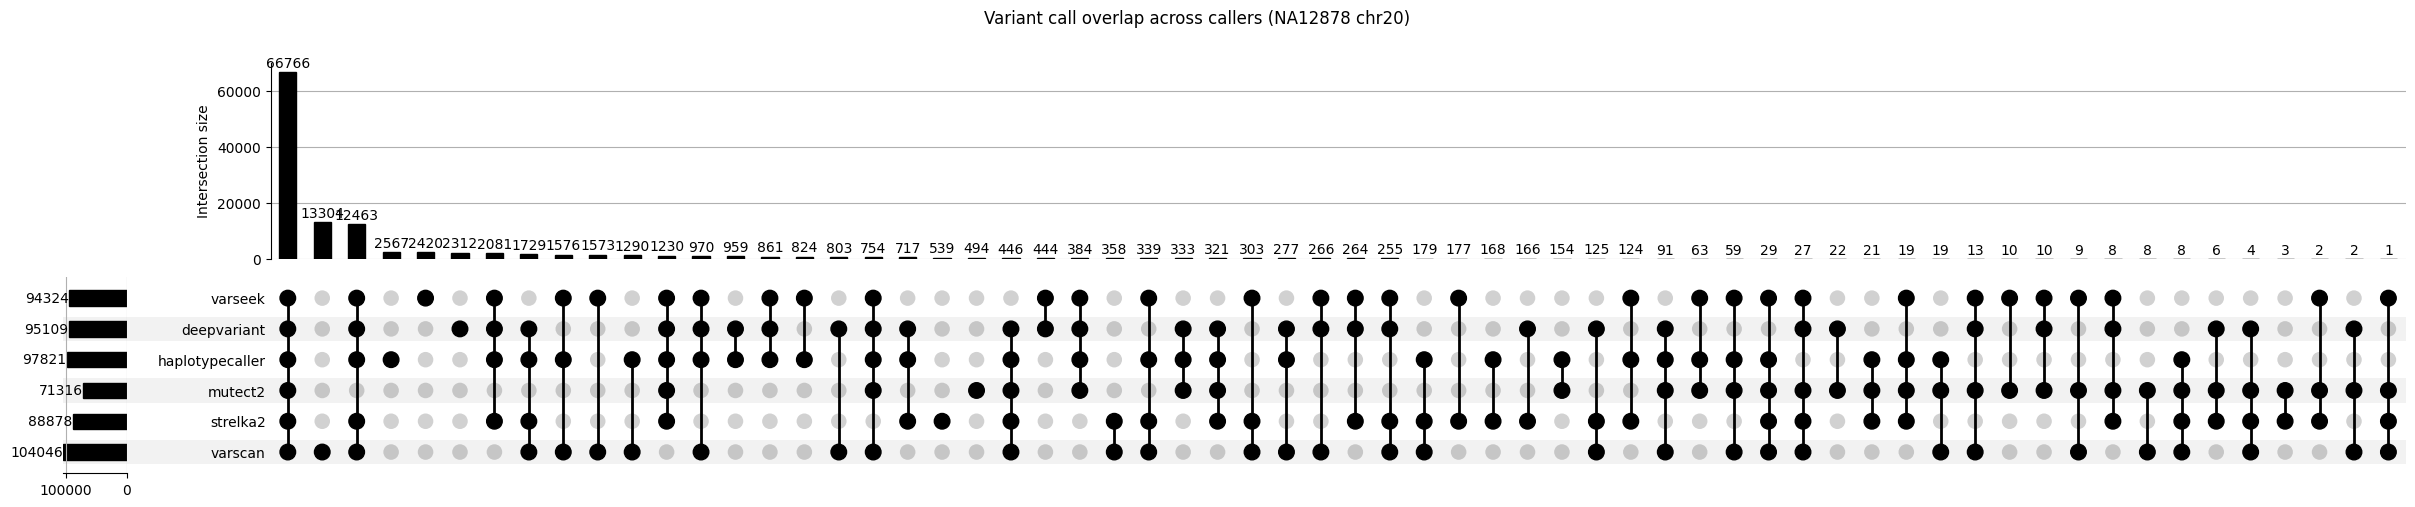

time: 3.23 s (started: 2026-08-12 22:26:40 -07:00)


In [35]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Normalized (left-aligned, multiallelic-split) VCFs -> common coordinate representation.
# `varseek_preliminary` is the vk denovo seed rather than a separate tool, so it is left out;
# uncomment its entry below to put it back in the plot.
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(varseek_calls_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    # "varseek_preliminary": add_normalized_before_first_dot(variants_vcf),
    "strelka2": add_normalized_before_first_dot(insert_suffix_before_first_dot(strelka_vcf, "_nonref")),
    "varscan": add_normalized_before_first_dot(insert_suffix_before_first_dot(varscan_vcf, "_nonref")),
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (NA12878 chr20)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Precision vs recall against the GIAB truth

Because NA12878 has a gold-standard truth set, every caller can be scored directly instead of
only compared to the others: each tool's normalized chr20 calls go through the same `hap.py`
benchmark (same truth VCF, same high-confidence BED, same `scmp-somatic` allele-matching engine,
which ignores genotypes so the sites-only varseek track is not unfairly penalized).

In [36]:
# ---------------------------------------------------------------------------
# Run hap.py for each of the other callers against the same GIAB truth, reusing
# the chr20-restricted normalized VCFs built above.  Guarded by output existence,
# so re-running the cell is cheap.
# ---------------------------------------------------------------------------
def run_happy_for_tool(query_vcf, tool, happy_dir=None):
    """hap.py: GIAB truth vs one caller's normalized VCF. Returns the summary CSV path."""
    happy_dir = happy_dir or os.path.join(root, "happy_output_per_tool", tool)
    prefix = os.path.join(os.path.abspath(happy_dir), f"{tool}_vs_giab_truth")
    summary = f"{prefix}.summary.csv"
    if os.path.isfile(summary):
        print(f"[{tool}] hap.py summary exists - skipping")
        return summary
    os.makedirs(happy_dir, exist_ok=True)
    # hap.py needs a bgzipped + tabix-indexed query
    if not query_vcf.endswith(".gz"):
        gz = query_vcf + ".gz"
        if not os.path.isfile(gz):
            subprocess.run(f"bgzip -c {query_vcf} > {gz}", shell=True, check=True)
        query_vcf = gz
    if not os.path.isfile(query_vcf + ".tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", query_vcf], check=True)

    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_vcf)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
    return summary


# Same normalized, chr20-restricted call sets used by the upset plot.  varseek reuses
# the hap.py run from the top of the notebook (identical truth/BED/engine).
happy_summaries = {"varseek": os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")}
for tool, raw_vcf in caller_raw_vcfs.items():
    if tool == "varseek":
        continue
    if not raw_vcf or not os.path.exists(raw_vcf):
        print(f"WARNING: {tool} VCF missing ({raw_vcf}); skipping hap.py.")
        continue
    happy_summaries[tool] = run_happy_for_tool(
        add_normalized_before_first_dot(filter_to_variant_calls(raw_vcf)), tool)

print("\nhap.py summaries:")
for tool, s in happy_summaries.items():
    print(f"  {tool:16s} {s}")

[varseek_preliminary] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
[deepvariant] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[haplotypecaller] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[mutect2] hap.py summary exists - skipping
Filtered file data/na12878_chr20/strelka_out/results/variants/variants_nonref.vcf.gz already exists. Skipping filtering.
[strelka2] hap.py summary exists - skipping
Filtered file data/na12878_chr20/varscan_out/varscan_variants_with_contigs_nonref.vcf already exists. Skipping filtering.
[varscan] hap.py summary exists - skipping

hap.py summaries:
  varseek          data/na12878_chr20/hap

precision_%                recall_%                \
type                                ALL   INDEL    SNP      ALL  INDEL    SNP   
label                                                                           
varseek_denovo                    98.75   98.14  98.85    95.37  93.20  95.69   
varseek_genotyping (cosmic)       99.55  100.00  99.55    92.89  55.56  93.60   
gatk_haplotypecaller              98.62   99.19  98.53    97.73  98.22  97.65   
gatk_mutect2                      99.28   99.88  99.21    80.18  69.13  81.86   
strelka2                          99.71   98.66  99.87    94.37  95.94  94.14   
varscan                           96.69   98.82  96.41    93.63  85.84  94.82   
deepvariant                       99.78   99.33  99.85    97.11  98.00  96.97   

                               F1              
type                          ALL INDEL   SNP  
label                                          
varseek_denovo               0.97  0.96  0.97  
varseek_genotyping (cosmic)  0.96  0.71  0.96  
gatk_haplotypecaller         0.98  0.99  0.98  
gatk_mutect2                 0.89  0.82  0.90  
strelka2                     0.97  0.97  0.97  
varscan                      0.95  0.92  0.96  
deepvariant                  0.98  0.99  0.98

Saved data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/precision_recall_all_tools.png


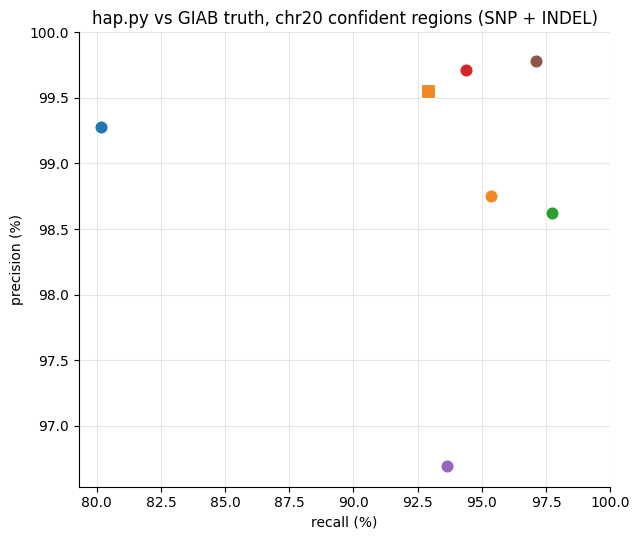

time: 526 ms (started: 2026-08-12 22:26:43 -07:00)


In [37]:
# --- precision vs recall for every caller, straight from the hap.py summaries ---------------
# One point per tool, SNP + INDEL pooled.  Plotted WITHOUT an in-axes legend: the callers pack
# into the top-right corner, so the legend is rendered separately at the bottom of the notebook
# (`plot_scatter_legend`) and placed by hand during figure assembly.
#
# `varseek_genotyping (cosmic)` is included but is NOT on the same recall axis as the rest:
# it is scored against GIAB (intersect) COSMIC rather than the full GIAB truth, because a catalog
# screen can only report what its catalog contains. Set the flag to False to drop it.
INCLUDE_VARSEEK_COSMIC = True

import matplotlib.pyplot as plt


def happy_confusion_counts(summary_csv):
    """{type: (TP, FP, FN)} from a hap.py summary CSV (PASS rows), plus an ALL row summing
    SNP + INDEL. TP/FN are truth-side, FP is query-side."""
    summ = pd.read_csv(summary_csv)
    summ = summ[summ["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL")}
    cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))
    return cms


scatter_summaries = dict(happy_summaries)
# The vk denovo seed is not a finished call set, so it is kept out of the figure; comment out
# the pop() to put `varseek_denovo_unfiltered` back into the scatter (and its legend).
scatter_summaries.pop("varseek_preliminary", None)
if INCLUDE_VARSEEK_COSMIC and os.path.isfile(summary_csv_cosmic):
    scatter_summaries["varseek_cosmic"] = summary_csv_cosmic

rows = []
for tool in order_tools(scatter_summaries):
    summary_path = scatter_summaries[tool]
    if not os.path.isfile(summary_path):
        print(f"WARNING: no hap.py summary for {tool}; skipping.")
        continue
    for typ, (tp, fp, fn) in happy_confusion_counts(summary_path).items():
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        rows.append({"tool": tool, "label": tool_label(tool), "type": typ, "TP": tp, "FP": fp, "FN": fn,
                     "precision_%": round(100 * prec, 2), "recall_%": round(100 * rec, 2),
                     "F1": round(2 * prec * rec / (prec + rec), 4) if prec + rec else 0.0})
happy_all_tools = pd.DataFrame(rows)
# `tool` keeps the internal id (hap.py output dirs); `label` is the figure name.
scatter_tools = list(dict.fromkeys(happy_all_tools["tool"]))
display(happy_all_tools.pivot(index="label", columns="type",
                              values=["precision_%", "recall_%", "F1"])
        .reindex([tool_label(t) for t in scatter_tools]).round(2))
happy_all_tools.to_csv(os.path.join(happy_out, "happy_all_tools_summary.csv"), index=False)

# Points only, no legend -- see the standalone legend cell at the bottom of the notebook.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for tool in scatter_tools:
    r = happy_all_tools[(happy_all_tools.tool == tool) & (happy_all_tools.type == "ALL")].iloc[0]
    # genotyping mode is the same tool as varseek_denovo, so it carries the same colour and
    # point size and is set apart by a square marker
    cosmic = tool == "varseek_cosmic"
    ax.scatter(r["recall_%"], r["precision_%"], s=90,
               marker="s" if cosmic else "o",
               color=TOOL_COLORS.get(tool, DEFAULT_TOOL_COLOR),
               edgecolors="white",
               linewidths=0.8, zorder=3,
               label=tool_label(tool))
ax.set_xlabel("recall (%)"); ax.set_ylabel("precision (%)")
ax.set_title("hap.py vs GIAB truth, chr20 confident regions (SNP + INDEL)")
ax.set_xlim(left=ax.get_xlim()[0], right=100); ax.set_ylim(bottom=ax.get_ylim()[0], top=100)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
pr_png = os.path.join(happy_out, "precision_recall_all_tools.png")
plt.savefig(pr_png, dpi=200, bbox_inches="tight")
print("Saved", pr_png)
plt.show()

### Supplementary figure: call-set overlap, all calls vs false positives

Panel (a) is the caller overlap over every call `hap.py` assessed; panel (b) restricts each
caller to the calls `hap.py` labeled **FP** against the same GIAB truth. Panel (b) is the
evidence for the claim that most of varseek's false positives are shared with the read
alignment-based callers rather than being specific to varseek.

Both panels are built from each tool's own `hap.py` annotated VCF (`FORMAT/BD` on the QUERY
sample), so the two panels live in one key space and (b) is exactly a subset of (a). That also
means panel (a) counts only calls inside the GIAB confident regions, which is a smaller set than
the standalone upset plot above (which spans all chr20 calls, assessed or not).

varseek genotyping is left out of both panels: it is scored against a different truth
(GIAB $\cap$ COSMIC), so its membership in an intersection would not mean the same thing.

varseek_denovo           assessed  76,979   FP    959


gatk_haplotypecaller     assessed  78,992   FP  1,091


gatk_mutect2             assessed  64,378   FP    461


strelka2                 assessed  75,450   FP    220


varscan                  assessed  77,195   FP  2,555


deepvariant              assessed  77,576   FP    167

varseek FPs also called by >=1 other tool: 584/959 (60.9%)



Saved data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/upset_calls_and_fps.pdf


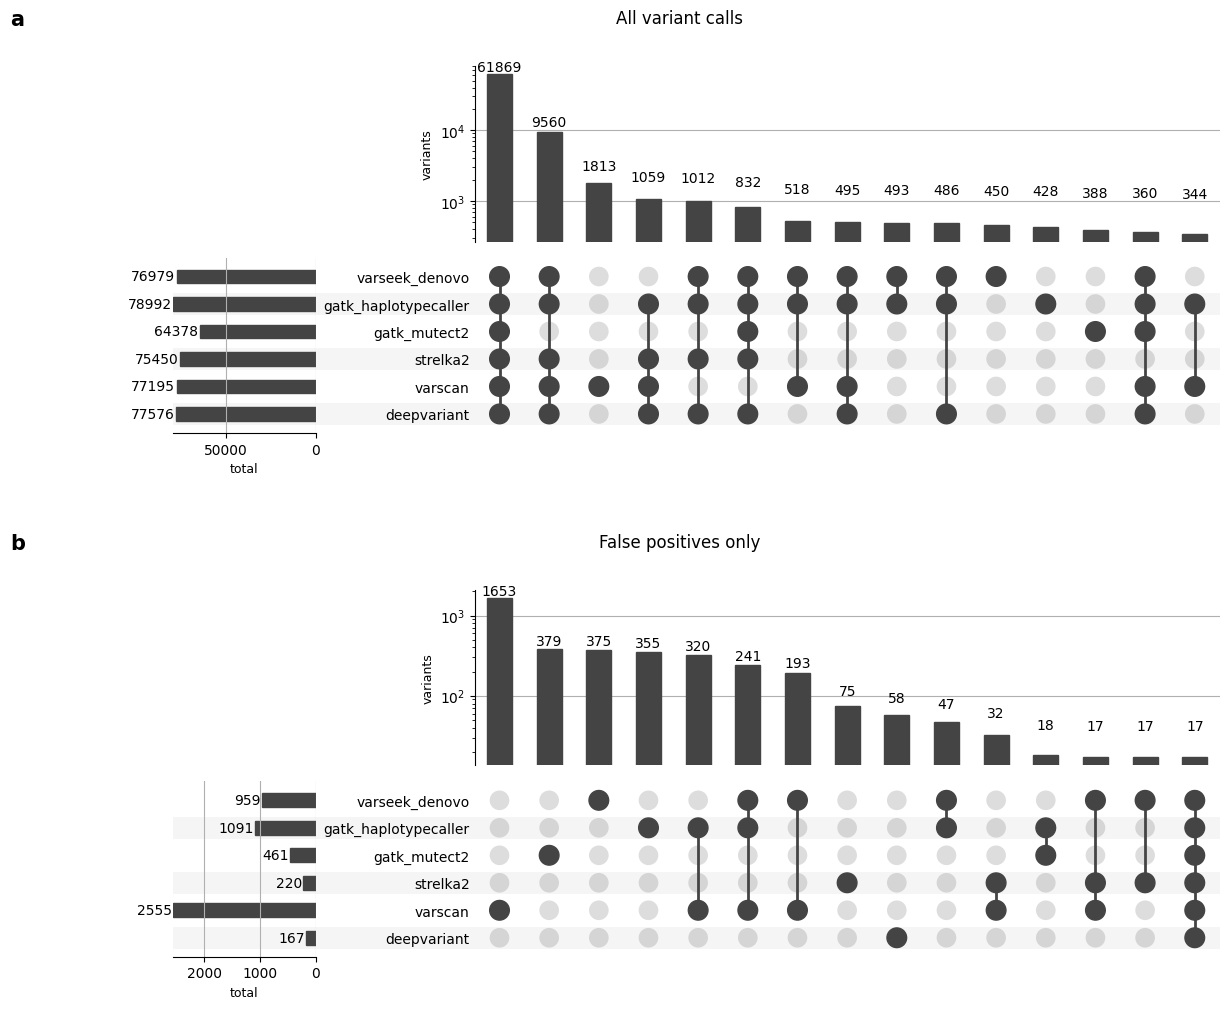

time: 5.8 s (started: 2026-08-12 22:26:44 -07:00)


In [38]:
# --- 2-panel upset: all assessed calls (a) and false positives only (b) --------------------
# The FP panel is the figure referenced by the manuscript's statement about varseek's false
# positives being shared with the other callers.
from upsetplot import from_contents, UpSet

UPSET_TOP = 15          # largest N intersections shown per panel; the tail is a long list of 1s


def happy_call_sets(summary_csv):
    """(POS, REF, ALT) of the calls hap.py assessed for one tool -> (all TP+FP, FP only).

    UNK records are dropped: those are calls outside the confident regions, which hap.py does
    not judge, so they belong in neither panel."""
    vcf = summary_csv.replace(".summary.csv", ".vcf.gz")
    if not os.path.isfile(vcf):
        return None, None
    allc, fps = set(), set()
    with gzip.open(vcf, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.rstrip("\n").split("\t")
            query = dict(zip(f[8].split(":"), f[10].split(":")))   # sample 2 = the query
            bd = query.get("BD")
            if bd in ("TP", "FP"):
                key = (f[1], f[3], f[4])
                allc.add(key)
                if bd == "FP":
                    fps.add(key)
    return allc, fps


# same tools as the upset plot above (the vk denovo seed and the COSMIC screen stay out)
upset_tools = [t for t in order_tools(happy_summaries) if t in caller_sets]
all_sets, fp_sets = {}, {}
for tool in upset_tools:
    a, f = happy_call_sets(happy_summaries[tool])
    if a is None:
        print(f"WARNING: no hap.py annotated VCF for {tool}; excluding.")
        continue
    all_sets[tool_label(tool)], fp_sets[tool_label(tool)] = a, f
    print(f"{tool_label(tool):24s} assessed {len(a):>7,}   FP {len(f):>6,}")

fp_total = len(fp_sets.get("varseek_denovo", ()))
if fp_total:
    shared = sum(1 for k in fp_sets["varseek_denovo"]
                 if any(k in s for n, s in fp_sets.items() if n != "varseek_denovo"))
    print(f"\nvarseek FPs also called by >=1 other tool: {shared:,}/{fp_total:,} "
          f"({100 * shared / fp_total:.1f}%)")

fig = plt.figure(figsize=(13.5, 10))
subfigs = fig.subfigures(2, 1, hspace=0.10)
for subfig, contents, title, letter in [
        (subfigs[0], all_sets, "All variant calls", "a"),
        (subfigs[1], fp_sets, "False positives only", "b")]:
    axes = UpSet(from_contents(contents), subset_size="count", show_counts=True,
                 sort_by="cardinality", sort_categories_by="-input",
                 max_subset_rank=UPSET_TOP, totals_plot_elements=3,
                 element_size=None, facecolor="#444444").plot(fig=subfig)
    axes["intersections"].set_yscale("log")     # one bar dwarfs the rest on both panels
    axes["intersections"].set_ylabel("variants", fontsize=9)
    axes["totals"].set_xlabel("total", fontsize=9)
    subfig.suptitle(title, fontsize=12, y=1.0)
    subfig.text(0.004, 1.0, letter, fontsize=15, fontweight="bold", va="top")

upset_fp_pdf = os.path.join(happy_out, "upset_calls_and_fps.pdf")
fig.savefig(upset_fp_pdf, bbox_inches="tight")
fig.savefig(upset_fp_pdf.replace(".pdf", ".png"), dpi=200, bbox_inches="tight")
print("\nSaved", upset_fp_pdf)
plt.show()


### Tool runtimes

Wall-clock runtime for each caller, read back from `tool_runtimes.json`. The three
varseek stages (`vk denovo`, `vk ref`, `vk count`) are recorded separately in the JSON
but summed into a single **varseek** bar (shown stacked so the per-stage breakdown is
still visible). Any tool that was skipped on this run (output already existed) keeps its
previously recorded time.

Recorded runtimes:
  vk denovo            12.8 s  (  0.21 min)
  vk ref              120.2 s  (  2.00 min)
  vk count           1102.0 s  ( 18.37 min)
  deepvariant         941.6 s  ( 15.69 min)
  haplotypecaller    1727.5 s  ( 28.79 min)
  mutect2            1306.7 s  ( 21.78 min)
  strelka2            159.1 s  (  2.65 min)
  varscan             790.2 s  ( 13.17 min)
  varseek (total)    1235.0 s  ( 20.58 min)


Saved plot -> data/na12878_chr20/tool_runtimes.png


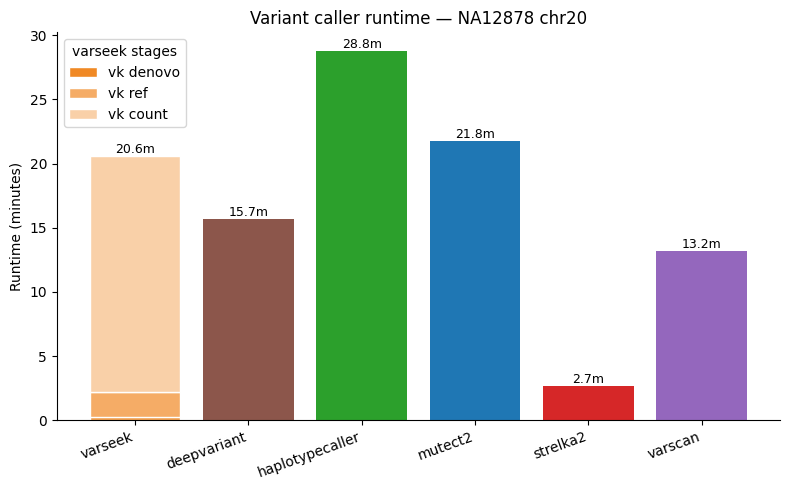

time: 340 ms (started: 2026-08-12 22:26:49 -07:00)


In [39]:
import matplotlib.pyplot as plt

rt = load_runtimes()

varseek_stages = ["vk denovo", "vk ref", "vk count"]
other_tools = ["deepvariant", "haplotypecaller", "mutect2", "strelka2", "varscan", "vartrix"]

print("Recorded runtimes:")
for name in varseek_stages + other_tools:
    if name in rt:
        print(f"  {name:16s} {rt[name]:8.1f} s  ({rt[name]/60:6.2f} min)")
varseek_total = sum(rt.get(s, 0.0) for s in varseek_stages)
print(f"  {'varseek (total)':16s} {varseek_total:8.1f} s  ({varseek_total/60:6.2f} min)")

# --- build bars: one stacked varseek bar + one bar per other tool present ----
present_others = [(t, rt[t]) for t in other_tools if t in rt]
stage_vals = [rt.get(s, 0.0) for s in varseek_stages]

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["varseek"] + [t for t, _ in present_others]
x = list(range(len(labels)))

# stacked varseek bar (per-stage segments) -- three tints of varseek's orange, so the bar
# reads as one tool while still showing where its time goes
stage_colors = ["#f08925", "#f5ac66", "#f9d0a8"]
bottom = 0.0
for val, stage, c in zip(stage_vals, varseek_stages, stage_colors):
    ax.bar(0, val / 60, bottom=bottom / 60, color=c, edgecolor="white", label=stage)
    bottom += val

# other tools, each in its own colour from the shared palette
for i, (t, v) in enumerate(present_others, start=1):
    ax.bar(i, v / 60, color=TOOL_COLORS.get(t, DEFAULT_TOOL_COLOR))

# annotate totals on top of each bar
totals = [varseek_total] + [v for _, v in present_others]
for xi, tot in zip(x, totals):
    ax.text(xi, tot / 60, f"{tot/60:.1f}m", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Runtime (minutes)")
ax.set_title("Variant caller runtime — NA12878 chr20")
ax.legend(title="varseek stages", loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

runtime_plot_png = os.path.join(root, "tool_runtimes.png")
plt.savefig(runtime_plot_png, dpi=200, bbox_inches="tight")
print(f"Saved plot -> {runtime_plot_png}")
plt.show()

### Standalone scatterplot legend

The precision/recall scatterplot above is drawn with no in-axes legend (every caller packs
into the top-right corner, so an inline legend either collides with the points or covers
them). The cell below renders the *same* handles -- colour, marker size, edge styling -- as
dummy points on their own figure, with no data attached, in the canonical `TOOL_ORDER`.
Call `plot_scatter_legend()` for the tools actually in the scatterplot, or pass an explicit
`tools=[...]` list.

In [40]:
# --- dummy (data-free) legend for the precision/recall scatterplot --------------------
# Renders the same handles the scatterplot uses -- colour from TOOL_COLORS, s=90, white
# edge, square marker for the genotyping-mode varseek_cosmic point -- onto a figure with
# no axes, so it can be placed independently during figure assembly.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def scatter_legend_handles(tools, labels=None):
    """Line2D handles matching the scatterplot's marker styling, one per tool."""
    labels = labels or {}
    handles = []
    for tool in tools:
        color = TOOL_COLORS.get(tool, DEFAULT_TOOL_COLOR)
        cosmic = tool == "varseek_cosmic"
        handles.append(Line2D([], [], linestyle="none", marker="s" if cosmic else "o",
                              markersize=90 ** 0.5,          # scatter s= is area in pt^2
                              markerfacecolor=color, color=color,
                              markeredgecolor="white",
                              markeredgewidth=0.8,
                              label=labels.get(tool, tool_label(tool))))
    return handles


def plot_scatter_legend(tools=None, labels=None, ncol=1, fontsize=9, title=None,
                        save_path=None, figsize=None, show=True):
    """Draw the scatterplot's legend on its own figure and return (fig, legend).

    tools     : internal tool ids, in legend order. Defaults to the tools plotted in the
                precision/recall scatterplot above (already in TOOL_ORDER), falling back
                to TOOL_ORDER itself.
    labels    : optional {tool: display name} overrides; defaults to TOOL_DISPLAY_NAMES.
    save_path : if given, write the legend PNG there (tightly cropped, transparent).
    """
    if tools is None:
        try:
            tools = list(scatter_tools)
        except NameError:
            tools = list(TOOL_ORDER)
    # matches the scatterplot, which leaves the vk denovo seed out; drop this line to legend it
    tools = [t for t in tools if t != "varseek_preliminary"]
    tools = order_tools(tools)
    handles = scatter_legend_handles(tools, labels)
    nrow = -(-len(handles) // ncol)
    figsize = figsize or (2.9 * ncol, 0.32 * nrow + (0.35 if title else 0.15))

    fig = plt.figure(figsize=figsize)
    leg = fig.legend(handles=handles, loc="center", ncol=ncol, title=title,
                     fontsize=fontsize, frameon=False, handletextpad=0.3,
                     labelspacing=0.6, borderpad=0.0)
    fig.patch.set_alpha(0.0)
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight", transparent=True)
        print("Saved", save_path)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, leg


legend_png = os.path.join(happy_out, "precision_recall_all_tools_legend.png")
plot_scatter_legend(save_path=legend_png)

# Horizontal strip variant, e.g. for a legend row under a set of panels:
legend_row_png = os.path.join(happy_out, "precision_recall_all_tools_legend_row.png")
plot_scatter_legend(ncol=4, save_path=legend_row_png)

Saved data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/precision_recall_all_tools_legend.png


<Figure size 290x239 with 0 Axes>

Saved data/na12878_chr20/happy_output_seed_c2v10_k41_thr5_srr_pb_snpvaf25_indelvaf10/precision_recall_all_tools_legend_row.png


<Figure size 1160x79 with 0 Axes>

(<Figure size 1160x79 with 0 Axes>,
 <matplotlib.legend.Legend at 0x7fbd933f5ff0>)

time: 93.3 ms (started: 2026-08-12 22:26:50 -07:00)
